<h2>Apri questo notebook in Google Colab</h2>

<div align="left" style="margin: 20px 0;">
  <a href="https://colab.research.google.com/github/LeonardoCofone/The-AI-Handbook/blob/main/chapter_9_Machine_Learning.ipynb" target="_parent">
    <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
  </a>
</div>

# Capitolo 9, Feature Engineering

Il capitolo piu importante del libro, diceva Andrew Ng: *"Applied machine learning is basically feature engineering."*  
In questo notebook costruiamo feature con le nostre mani e vediamo, numeri alla mano, quanto migliorano un modello. Sporcati le mani: cambia le trasformazioni e guarda l'effetto.

## 0. Setup

In [1]:
%pip install numpy pandas matplotlib scikit-learn

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import OneHotEncoder, PolynomialFeatures
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import cross_val_score

np.random.seed(42)
print('Setup completato!')

Setup completato!


## 1. Dummy variables: da categorie a numeri

Gli algoritmi vogliono numeri, non stringhe. Il one-hot encoding crea una colonna binaria per ogni categoria, senza inventare ordini artificiali.

In [3]:
df = pd.DataFrame({'colore_auto': ['rosso', 'blu', 'verde', 'rosso']})
print('Prima:'); print(df)

encoder = OneHotEncoder(drop='first', sparse_output=False)
encoded = encoder.fit_transform(df[['colore_auto']])
encoded_df = pd.DataFrame(encoded, columns=encoder.get_feature_names_out())
print('\nDopo (drop=first evita la dummy trap):'); print(encoded_df)

Prima:
  colore_auto
0       rosso
1         blu
2       verde
3       rosso

Dopo (drop=first evita la dummy trap):
   colore_auto_rosso  colore_auto_verde
0                1.0                0.0
1                0.0                0.0
2                0.0                1.0
3                1.0                0.0


## 2. Interaction features: l'effetto combinato

Un reddito alto pesa diversamente a 25 o a 55 anni. I modelli lineari non lo vedono da soli: creiamo noi la feature di interazione.

In [4]:
df2 = pd.DataFrame({
    'eta': [25, 55, 40, 30],
    'reddito': [30000, 30000, 50000, 45000]
})
df2['eta_per_reddito'] = df2['eta'] * df2['reddito']
print(df2)

   eta  reddito  eta_per_reddito
0   25    30000           750000
1   55    30000          1650000
2   40    50000          2000000
3   30    45000          1350000


## 3. Trasformazione logaritmica su distribuzione heavy-tail

Redditi e prezzi hanno code lunghe: pochi valori enormi. Il log1p le comprime in una campana simmetrica, piu facile da imparare.

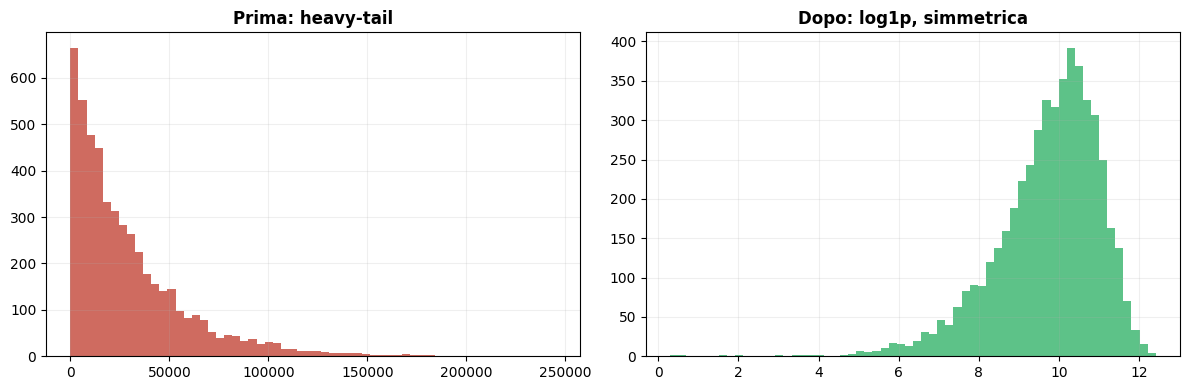

In [5]:
redditi = np.random.exponential(scale=30000, size=5000)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(redditi, bins=60, color='#C0392B', alpha=0.75)
axes[0].set_title('Prima: heavy-tail', fontweight='bold')
axes[1].hist(np.log1p(redditi), bins=60, color='#27AE60', alpha=0.75)
axes[1].set_title('Dopo: log1p, simmetrica', fontweight='bold')
for ax in axes: ax.grid(True, alpha=0.2)
plt.tight_layout(); plt.show()

## 4. Binning: catturare relazioni non lineari

A volte una variabile continua e piu utile a fasce. `pd.cut` divide in bucket con etichette parlanti.

In [6]:
eta = pd.Series([15, 22, 30, 45, 62, 78, 90])
fascia = pd.cut(eta, bins=[0, 18, 35, 60, 100],
                labels=['giovane', 'adulto', 'maturo', 'anziano'])
print(pd.DataFrame({'eta': eta, 'fascia': fascia}))

   eta   fascia
0   15  giovane
1   22   adulto
2   30   adulto
3   45   maturo
4   62  anziano
5   78  anziano
6   90  anziano


## 5. Aggregazioni con groupby

Con dati transazionali contano i pattern aggregati, non i singoli eventi. `transform` riporta la statistica su ogni riga.

In [7]:
vendite = pd.DataFrame({
    'cliente_id': ['A', 'A', 'B', 'B', 'B'],
    'importo': [100, 150, 200, 50, 80]
})
# Totale per cliente riportato su ogni riga
vendite['totale_cliente'] = vendite.groupby('cliente_id')['importo'].transform('sum')
vendite['num_acquisti'] = vendite.groupby('cliente_id')['importo'].transform('count')
print(vendite)

  cliente_id  importo  totale_cliente  num_acquisti
0          A      100             250             2
1          A      150             250             2
2          B      200             330             3
3          B       50             330             3
4          B       80             330             3


## 6. Derived features: la domain knowledge in azione

Qui il feature engineering diventa arte. Il modello non sa che prezzo/superficie = prezzo al mq. Glielo diciamo noi.

In [8]:
case = pd.DataFrame({
    'prezzo_totale': [300000, 450000, 200000],
    'superficie': [100, 150, 80],
    'anno_costruzione': [1990, 2010, 1975]
})
case['prezzo_mq'] = case['prezzo_totale'] / case['superficie']
case['eta_immobile'] = 2026 - case['anno_costruzione']
print(case)

   prezzo_totale  superficie  anno_costruzione  prezzo_mq  eta_immobile
0         300000         100              1990     3000.0            36
1         450000         150              2010     3000.0            16
2         200000          80              1975     2500.0            51


## 7. La prova del nove: le feature migliorano il modello?

Costruiamo un dataset dove il target dipende dal **prezzo al mq**, non dalle feature grezze.  
Alleniamo un modello lineare prima con le feature grezze, poi con la feature derivata. Guarda la differenza.

In [9]:
n = 500
superficie = np.random.randint(50, 200, n)
prezzo_mq_reale = np.random.randint(1500, 4000, n)
prezzo_totale = superficie * prezzo_mq_reale + np.random.randn(n) * 5000

# Target: un indice che dipende dal prezzo al mq
y = prezzo_mq_reale * 2 + np.random.randn(n) * 100

# Modello 1: solo feature grezze
X_grezze = np.column_stack([superficie, prezzo_totale])
score_grezze = cross_val_score(LinearRegression(), X_grezze, y, cv=5, scoring="r2").mean()

# Modello 2: con la feature derivata prezzo_mq
prezzo_mq = prezzo_totale / superficie
X_derivata = np.column_stack([superficie, prezzo_totale, prezzo_mq])
score_derivata = cross_val_score(LinearRegression(), X_derivata, y, cv=5, scoring="r2").mean()

print(f'R2 con feature grezze:   {score_grezze:.3f}')
print(f'R2 con feature derivata: {score_derivata:.3f}')
print(f'Miglioramento: la feature di dominio cambia tutto!')

R2 con feature grezze:   0.881
R2 con feature derivata: 0.989
Miglioramento: la feature di dominio cambia tutto!


## 8. Feature importance: quali feature contano davvero

Random Forest misura l'importanza di ogni feature. Aggiungiamo due colonne di rumore puro e vediamo se il modello le smaschera.

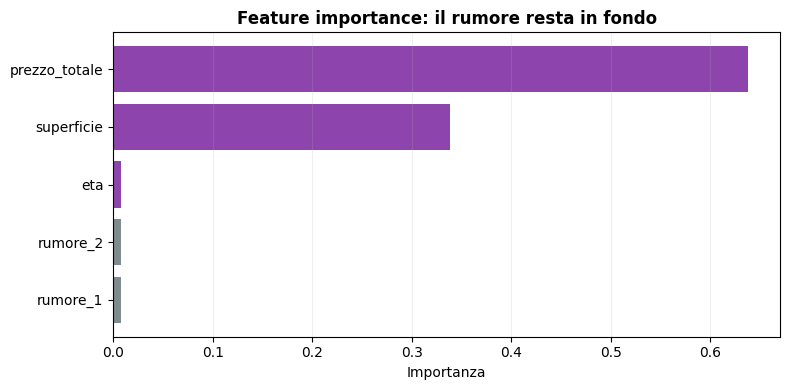

In [10]:
eta = np.random.randint(20, 70, n)
rumore_1 = np.random.randn(n)
rumore_2 = np.random.randn(n)
X_full = np.column_stack([superficie, prezzo_totale, eta, rumore_1, rumore_2])
nomi = ['superficie', 'prezzo_totale', 'eta', 'rumore_1', 'rumore_2']

rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_full, y)

imp = pd.Series(rf.feature_importances_, index=nomi).sort_values()
colori = ['#7F8C8D' if 'rumore' in n else '#8E44AD' for n in imp.index]
plt.figure(figsize=(8, 4))
plt.barh(imp.index, imp.values, color=colori)
plt.xlabel('Importanza'); plt.title('Feature importance: il rumore resta in fondo', fontweight='bold')
plt.grid(True, alpha=0.2, axis="x"); plt.tight_layout(); plt.show()

Abbiamo costruito feature di ogni tipo (dummy, interazioni, trasformazioni, aggregazioni, derivate) e visto **numeri alla mano** che una buona feature di dominio puo cambiare completamente le performance di un modello.

La lezione di Andrew Ng resta la piu importante del libro: il machine learning applicato e, prima di tutto, feature engineering.

Nel prossimo capitolo lasciamo la regressione e affrontiamo il primo grande problema di classificazione: la **Regressione Logistica**.